In [16]:
import numpy as np
import json
import pandas as pd
import pyarrow.parquet as pq
from tqdm.auto import tqdm
import os
import xgboost as xgb
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import hist
import importlib
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# le = OrdinalEncoder

import mplhep as hep
plt.style.use([hep.style.CMS])
from common_bb_cc import common_mc
import batch_iterator
importlib.reload(batch_iterator)
from batch_iterator import Iterator
# from sklearn.model_selection import train_test_split


In [17]:
import batch_iterator
importlib.reload(batch_iterator)
from batch_iterator import Iterator

params = {
    # 'n_estimators':100,  # number of boosting rounds (i.e. number of decision trees)
    'max_depth':8,  # max depth of each decision tree
    'learning_rate':0.5,
    # 'early_stopping_rounds':20,  #Remove this # how many rounds to wait to see if the loss is going down
    # 'missing': np.nan,
    # 'scale_pos_weight': pos_weight,
    'eval_metric':'merror',
    'objective': 'multi:softmax',
    'num_class': 4, 
    'verbosity':1,
    # "tree_method": "hist"
}

eval_result={}
data_dir = "/uscms/home/bweiss/nobackup/hbb-run3/data/4cat_BDT_data_22"
file_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".parquet")]
metadata_dir = os.path.join(data_dir, "metadata.pkl")
train_files = file_paths[:8]
val_files = file_paths[8:]

#small sample
# train_files = file_paths[:8]
# val_files = file_paths[8:10]
print('val files: ', len(val_files))
print('train files: ', len(train_files))

cache_files = [file for file in os.listdir('./') if "cache-" in file]
if len(cache_files)>0:
    print('removing cache files: ', cache_files)
    for cache in cache_files:
        os.remove('./'+cache)
        
it_train = Iterator(device="cpu", file_paths=train_files, metadata_path = metadata_dir)
it_val = Iterator(device="cpu", file_paths=val_files, metadata_path = metadata_dir)

Xy_train = xgb.ExtMemQuantileDMatrix(it_train)
Xy_val = xgb.ExtMemQuantileDMatrix(it_val, ref=Xy_train)


val files:  2
train files:  8
removing cache files:  ['cache-0x557de2a8d620.gradient_index.page', 'cache-0x557de2a31930.gradient_index.page']


/tmp/ipykernel_966113/10929965.py:41: UserWarning: [14:30:50] WARNING: /workspace/src/data/sparse_page_source.cc:25: External memory cache file ./cache-0x557de2a8d620.gradient_index.page is missing.
  Xy_train = xgb.ExtMemQuantileDMatrix(it_train)
/tmp/ipykernel_966113/10929965.py:41: UserWarning: [14:30:50] WARNING: /workspace/src/data/sparse_page_source.cc:28: Couldn't remove external memory cache file ./cache-0x557de2a8d620.gradient_index.page; you may want to remove it manually
  Xy_train = xgb.ExtMemQuantileDMatrix(it_train)
/tmp/ipykernel_966113/10929965.py:42: UserWarning: [14:30:53] WARNING: /workspace/src/data/sparse_page_source.cc:25: External memory cache file ./cache-0x557de2a31930.gradient_index.page is missing.
  Xy_val = xgb.ExtMemQuantileDMatrix(it_val, ref=Xy_train)
/tmp/ipykernel_966113/10929965.py:42: UserWarning: [14:30:53] WARNING: /workspace/src/data/sparse_page_source.cc:28: Couldn't remove external memory cache file ./cache-0x557de2a31930.gradient_index.page; yo

In [18]:
model = xgb.train(params, 
         Xy_train, 
         100, #100
         # evals = [(DM_train, 'train'), (DM_test, 'test')],
         evals=[(Xy_train, "Train"), (Xy_val, "Val")],
         # evals_result = evals_result,
         # verbosity = 1
         )

[0]	Train-merror:0.31958	Val-merror:0.39882
[1]	Train-merror:0.29417	Val-merror:0.38205
[2]	Train-merror:0.28200	Val-merror:0.37879
[3]	Train-merror:0.27629	Val-merror:0.37506
[4]	Train-merror:0.27107	Val-merror:0.37022
[5]	Train-merror:0.26703	Val-merror:0.36615
[6]	Train-merror:0.26306	Val-merror:0.36607
[7]	Train-merror:0.26008	Val-merror:0.36628
[8]	Train-merror:0.25670	Val-merror:0.36958
[9]	Train-merror:0.25353	Val-merror:0.36751
[10]	Train-merror:0.25126	Val-merror:0.37066
[11]	Train-merror:0.24826	Val-merror:0.37202
[12]	Train-merror:0.24536	Val-merror:0.37105
[13]	Train-merror:0.24348	Val-merror:0.37058
[14]	Train-merror:0.24182	Val-merror:0.37000
[15]	Train-merror:0.24022	Val-merror:0.37089
[16]	Train-merror:0.23815	Val-merror:0.36888
[17]	Train-merror:0.23660	Val-merror:0.37200
[18]	Train-merror:0.23507	Val-merror:0.37097
[19]	Train-merror:0.23329	Val-merror:0.37014
[20]	Train-merror:0.23156	Val-merror:0.37009
[21]	Train-merror:0.22982	Val-merror:0.37334
[22]	Train-merror:0.

In [12]:
# features = model.feature_names
importance = model.get_score()
# print(importance, type(importance))
imps = [imp for k , imp in importance.items()]
fi = pd.DataFrame({'features': importance.keys(), 'importance': imps})
fi = fi.sort_values(by = 'importance', ascending=False).reset_index(drop=True)
print(fi[:61])

                  features  importance
0                     nJet       276.0
1             FatJet0_n3b1       267.0
2      FatJet1_ParTmassX2p       213.0
3         FatJet1_ParTPQCD       179.0
4         Jet1_btagPNetQvG       175.0
5              VBFPair_mjj       174.0
6             VBFPair_deta       170.0
7         Jet0_btagPNetQvG       166.0
8                  Jet0_pt       162.0
9             FatJet0_n2b1       158.0
10             FatJet1_msd       152.0
11             FatJet0_eta       137.0
12     FatJet1_ParTPTopbWq       136.0
13                 Jet1_pt       132.0
14        FatJet1_ParTPXqq       125.0
15        FatJet1_ParTPXcs       121.0
16              FatJet1_pt       115.0
17    FatJet1_ParTPTopbWqq       114.0
18    JetClosestFatJet0_pt       104.0
19               Jet0_mass        98.0
20        Jet1_btagPNetCvL        92.0
21                Jet0_eta        87.0
22   JetClosestFatJet0_eta        86.0
23        Jet2_btagPNetQvG        79.0
24                Jet1_et

In [13]:
model.save_model('BatchedBDT_4Cat_26Aug11_TEST.json')

In [14]:
booster = xgb.XGBClassifier()
booster.load_model('./BatchedBDT_4Cat_26Aug11_TEST.json')
# dir(booster)

vbf
vh
ggf
ttbar
0 vbf
N vbf:  7.6303405730777225
1 vh
N vh:  0.3361366187378403
2 ggf
N ggf:  7.16456420708359
----------------------------------------
Predicted vbf purity: 0.504283900355521)
contains 357.0 VBF, 1243.0 VH, 6160.0 ggF
with yields: 0.504283900355521 VBF, 0.0222150352957395 VH, 0.4735010643487395 ggF
0 vbf
N vbf:  0.7411203499378021
1 vh
N vh:  3.9526961296474648
2 ggf
N ggf:  4.7738298636540115
----------------------------------------
Predicted vh purity: 0.41749511825291546)
contains 26.0 VBF, 9136.0 VH, 3468.0 ggF
with yields: 0.07827926002612322 VBF, 0.41749511825291546 VH, 0.5042256217209614 ggF
0 vbf
N vbf:  2.2256154870588865
1 vh
N vh:  1.4252415285463649
2 ggf
N ggf:  36.805936314210314
----------------------------------------
Predicted ggf purity: 0.9097591105196499)
contains 90.0 VBF, 4648.0 VH, 26521.0 ggF
with yields: 0.05501215751122489 VBF, 0.0352287319691252 VH, 0.9097591105196499 ggF
0 vbf
N vbf:  0.9553601814747792
1 vh
N vh:  2.053354656703547
2 ggf
N

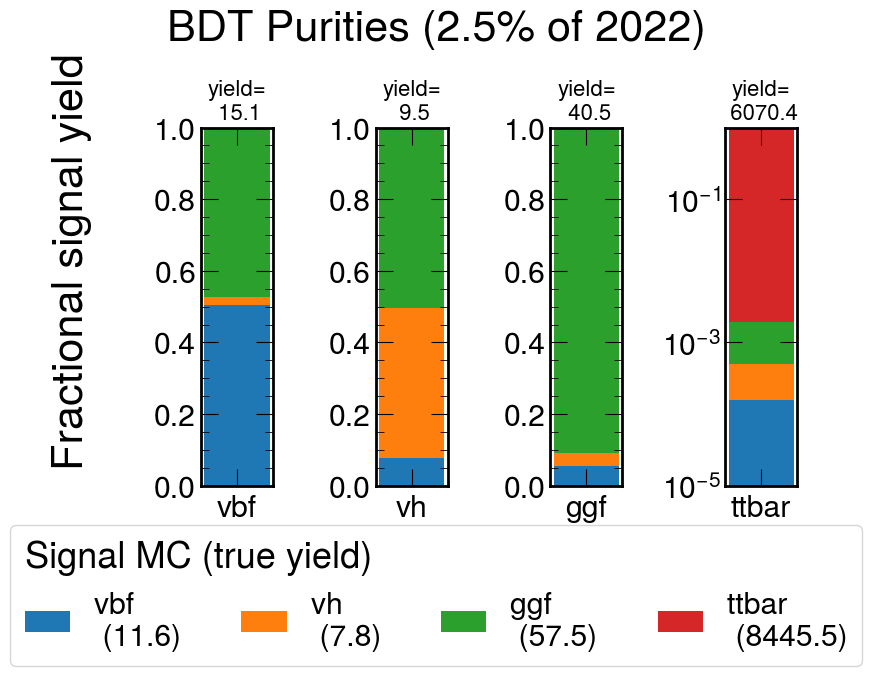

In [15]:
''' Purity plot'''
import mplhep as hep
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

plt.style.use([hep.style.CMS])

# colors = ['blue', 'red', 'green', 'purple', 'orange']
cat2label = {"vbf": 0,
             "vh": 1 ,
             "ggf": 2 ,
             "ttbar": 3
            }
label2cat = {0: "vbf",
             1: "vh" ,
             2: "ggf",
             3: "ttbar"
            }

omit_cols = ['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm', 'BDT_weight', 'BDT_cat_weight', 'BDT_era_weight', 'FatJet0_pt', 'FatJet0_msd']

def purity_plot(ax, x_test, category = '', use_weights = False, label =''): # produce a stacked histogram bar with the makeup of that category
    # cat_mask = X_test['category'] == category
    
    if category == 'ttbar':
        ax.set_yscale('log')
        ax.set_ylim([1e-5,1])
        order=[0,1,2,3]
    else:
        ax.set_ylim([0,1])
        order = [0,1,2,]

    # if category == 'ttbar':
    #     ax.set_yscale('log')
    #     ax.set_ylim([1e-7,1])
    #     order=[0,1,2,4,3]
    # else:
    #     ax.set_ylim([0,1])
    #     order = [0,1,2,4]
    
    Y_predict = booster.predict_proba(x_test.drop(omit_cols, axis=1))
    # Y_predict = booster.predict(x_test.drop(omit_cols, axis=1))
    # print(Y_predict[:40])
    
    Y_predict = np.argmax(Y_predict, axis = 1)
    cat_index = cat2label[category]
    pred_mask = Y_predict == cat_index
    X_pred = x_test[pred_mask]
    # print(X_pred)
    use_weights = int(use_weights)
    yields = np.zeros((4,2))
    bottom = 0
    for cat in order:
        truecat = label2cat[cat]
        print(cat, truecat)
        cat_mask = X_pred['category'] == truecat
        print(f'N {truecat}: ', np.sum(X_pred['finalWeight'][cat_mask].values, axis = 0))
        yields[cat][:] = [np.sum(cat_mask), 
                          np.sum(X_pred['finalWeight'][cat_mask].values, axis = 0)]
    sumw = np.sum(yields[:,1])
    yields[:,1] = yields[:,1]/ np.sum(yields[:,1])
    # print(yields)            
    
    for c in order:
    #     if c ==3:
    #         color = colors[4]
    #     else:
    #         color = colors[c]
        ax.bar(category, yields[c, use_weights], bottom=bottom, color = colors[c], label = label2cat[c])
        bottom += yields[c,use_weights]
    
        ax.set_title(f'yield=\n {round(sumw, 1)}', fontsize=16)
    print("----------------------------------------")
    print(f'Predicted {category} purity: {yields[cat_index,1]})')
    print(f'contains {yields[0][0]} VBF, {yields[1][0]} VH, {yields[2][0]} ggF')
    print(f'with yields: {yields[0][1]} VBF, {yields[1][1]} VH, {yields[2][1]} ggF')

# def cutBased_purity(ax, df, category = '', use_weights = False, label =''):
#     cut_mask = CutBased_events['true_cat']

    # return sumw
    # bins = [0,1]
    # _, _, patches = 
    # print(le.transform([category]))
    # print()
# print(len(X))
test_file = pd.read_parquet(val_files[-1])
true_yields = {}
for name, label in cat2label.items():
    print(name)
    cat_mask = test_file['category'] == name
    
    true_yields[name] = np.sum(test_file['finalWeight'][cat_mask])
test_data = test_file.drop(['category','y', 'weight', 'finalWeight', 'sum_genWeight', 'weight_nonorm', 'FatJet0_pt', 'FatJet0_msd'], axis=1)
DM_test = xgb.DMatrix(test_data, label=test_file['y'], missing = np.nan)


fig, axes  = plt.subplots(1,4, figsize = (8,6))
categories = ['vbf', 'vh', 'ggf', 'ttbar'#'tth'#'False'
             ]
for i in range(4):
    a = purity_plot(axes[i], test_file, use_weights = True, category = categories[i])

hands, legs = axes[3].get_legend_handles_labels()
legs = [f'{l} \n ({round(true_yields[l], 1)})' for j, l in enumerate(legs)]

fig.legend(#[f'{name} \n ({round(true_yields[name], 1)})' for name in categories],
           hands, legs,
           ncol = 4, title= 'Signal MC (true yield)', alignment='left', loc = 'lower center', frameon=True, bbox_to_anchor=(0.5, -0.2))
fig.suptitle('BDT Purities (2.5% of 2022)', x=0.5, y=0.92)
fig.supylabel('Fractional signal yield')
fig.tight_layout()
# plt.savefig('PurityPlot_3cat_WithAK4PNet_26Jul9.png', bbox_inches="tight")

                  features  importance
0       nJet_opphemFatJet0    0.000000
1         Jet4_btagPNetCvL    0.000000
2                      era    0.000000
3         Jet4_btagPNetCvB    0.000557
4                Jet3_mass    0.000822
5           Jet3_btagPNetB    0.001316
6         Jet4_btagPNetQvG    0.002538
7                 Jet3_phi    0.003059
8                Jet2_mass    0.004805
9           Jet2_btagPNetB    0.005024
10                Jet1_phi    0.005320
11          Jet0_btagPNetB    0.005646
12             FatJet1_phi    0.005817
13        Jet0_btagPNetCvL    0.006119
14   JetClosestFatJet0_phi    0.006157
15        FatJet1_ParTPXbb    0.006173
16     FatJet1_ParTPTopbWq    0.006759
17                 Jet1_pt    0.006761
18        Jet0_btagPNetCvB    0.007091
19             FatJet0_phi    0.007201
20     nJet_outsideFatJet0    0.007381
21               Jet1_mass    0.007567
22                Jet0_phi    0.007645
23                 nFatJet    0.007657
24                 Jet3_p

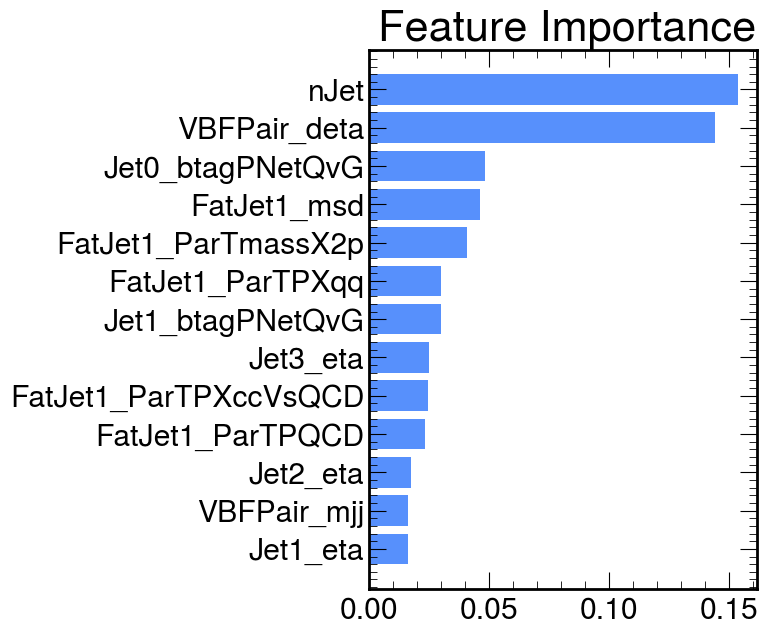

In [70]:
# features = model.feature_names
features = booster.get_booster().feature_names
importance = booster.feature_importances_

fi = pd.DataFrame({'features': features, 'importance': importance})
# fi = pd.DataFrame({'features': importance.keys(), 'importance': importance.values()})
fi = fi.sort_values(by = 'importance', ascending=True).reset_index(drop=True)
# print(fi['importance'])
print(fi[:55])

n = 13 #features
y=range(len(fi))
fig =plt.figure(figsize=(5,7))
plt.barh(y[-n:], fi['importance'][-n:])
plt.barh
plt.yticks(y[-n:], labels=fi['features'][-n:])
plt.title('Feature Importance', loc='right')
# plt.savefig('FeatureImportance_4cat_26Jun19.png', bbox_inches="tight")
plt.show()